<a href="https://colab.research.google.com/github/Ariyamilaara/2318105-AriyaMilaara-KlasifikasiCitraDaun-KNN/blob/main/2318105AriyaMilaaraKlasifikasiCitraDaunMetodeKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Library**

In [ ]:
# Library standar Python
import os
import zipfile
from pathlib import Path

# Manipulasi data
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Pengolahan citra
import cv2

# Tekstur GLCM
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.decomposition import PCA

# Pengaturan umum
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Cek versi
import sklearn
print('Semua library berhasil diimport!')
print(f'  NumPy      : {np.__version__}')
print(f'  Pandas     : {pd.__version__}')
print(f'  OpenCV     : {cv2.__version__}')
print(f'  Sklearn    : {sklearn.__version__}')

Semua library berhasil diimport!
  NumPy      : 2.0.2
  Pandas     : 2.2.2
  OpenCV     : 4.13.0
  Sklearn    : 1.6.1


# **2. Mount Google Drive & Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Path ke folder train
DATASET_PATH = '/content/drive/MyDrive/KOMPUTER VISION 2318105/Rice Leaf Disease'

# Definisi 2 kelas: Sehat vs Sakit
KELAS_SEHAT  = ['Healthy Rice Leaf']
KELAS_SAKIT  = ['Bacterial Leaf Blight', 'Brown Spot', 'Leaf Blast',
                 'Leaf scald', 'Narrow Brown Leaf Spot',
                 'Rice Hispa', 'Sheath Blight']

MAX_PER_KELAS = 200  # 200 sehat + 200 sakit = 400 total

all_images = []
all_labels = []

# Load gambar kelas SEHAT
for folder in KELAS_SEHAT:
    folder_path = Path(DATASET_PATH) / folder
    if not folder_path.exists():
        print(f'Folder tidak ditemukan: {folder_path}')
        continue
    imgs = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG']:
        imgs.extend(folder_path.glob(ext))
    imgs = imgs[:MAX_PER_KELAS]
    for img in imgs:
        all_images.append(img)
        all_labels.append('Sehat')
    print(f'  Sehat — {folder}: {len(imgs)} gambar')

# Load gambar kelas SAKIT (gabungan semua penyakit)
sakit_imgs = []
for folder in KELAS_SAKIT:
    folder_path = Path(DATASET_PATH) / folder
    if not folder_path.exists():
        print(f'Folder tidak ditemukan: {folder_path}')
        continue
    imgs = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG']:
        imgs.extend(folder_path.glob(ext))
    sakit_imgs.extend(imgs)
    print(f'  Sakit — {folder}: {len(imgs)} gambar')

# Ambil max 200 dari semua gambar sakit
sakit_imgs = sakit_imgs[:MAX_PER_KELAS]
for img in sakit_imgs:
    all_images.append(img)
    all_labels.append('Sakit')

print(f'\nTotal gambar dimuat : {len(all_images)}')
print(f'  Sehat : {all_labels.count("Sehat")} gambar')
print(f'  Sakit : {all_labels.count("Sakit")} gambar')

Mounted at /content/drive
  Sehat — Healthy Rice Leaf: 131 gambar
  Sakit — Bacterial Leaf Blight: 146 gambar
  Sakit — Brown Spot: 192 gambar
  Sakit — Leaf Blast: 217 gambar
  Sakit — Leaf scald: 162 gambar
  Sakit — Narrow Brown Leaf Spot: 114 gambar
  Sakit — Rice Hispa: 158 gambar
  Sakit — Sheath Blight: 202 gambar

Total gambar dimuat : 331
  Sehat : 131 gambar
  Sakit : 200 gambar


# **3. Tampilkan Sampel Gambar**

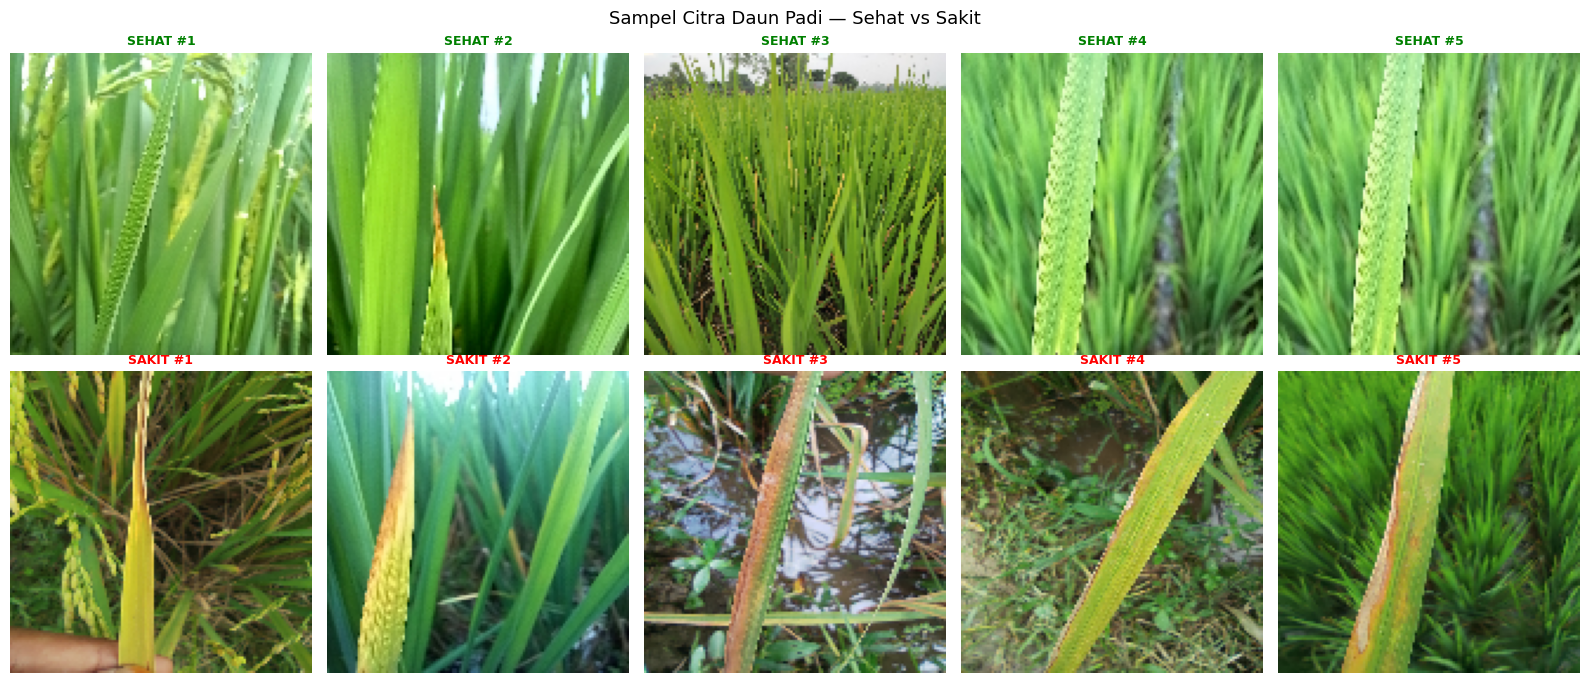

Sampel gambar ditampilkan!


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

# 5 sampel sehat
sehat_idx = [i for i, l in enumerate(all_labels) if l == 'Sehat'][:5]
# 5 sampel sakit
sakit_idx = [i for i, l in enumerate(all_labels) if l == 'Sakit'][:5]

for col, idx in enumerate(sehat_idx):
    img = cv2.imread(str(all_images[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    axes[col].imshow(img)
    axes[col].set_title(f'SEHAT #{col+1}', fontsize=9,
                        color='green', fontweight='bold')
    axes[col].axis('off')

for col, idx in enumerate(sakit_idx):
    img = cv2.imread(str(all_images[idx]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    axes[col+5].imshow(img)
    axes[col+5].set_title(f'SAKIT #{col+1}', fontsize=9,
                          color='red', fontweight='bold')
    axes[col+5].axis('off')

plt.suptitle('Sampel Citra Daun Padi — Sehat vs Sakit', fontsize=13)
plt.tight_layout()
plt.savefig('sampel_daun_padi.png', dpi=120, bbox_inches='tight')
plt.show()
print('Sampel gambar ditampilkan!')

# **4. Fungsi Ekstraksi Fitur Warna + Tekstur GLCM**

In [ ]:
def extract_features(image_path):
    """
    Mengekstrak 28 fitur dari satu citra daun padi:
    - 6  fitur : Mean & Std RGB
    - 18 fitur : Histogram HSV (6 bin x 3 channel)
    - 4  fitur : Tekstur GLCM (Contrast, Homogeneity, Energy, Correlation)
    Total      : 28 fitur per citra
    """
    # Load dan resize
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return None
    img_bgr  = cv2.resize(img_bgr, (128, 128))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    features = []

    # === BAGIAN 1: Fitur RGB (6 fitur) ===
    # Mean: rata-rata nilai piksel tiap channel
    # Std : seberapa bervariasi warna dalam citra
    img_float = img_rgb.astype(np.float32) / 255.0
    for ch in range(3):  # R, G, B
        features.append(np.mean(img_float[:, :, ch]))  # mean
        features.append(np.std(img_float[:, :, ch]))   # std

    # === BAGIAN 2: Histogram HSV (18 fitur) ===
    # Hue      : jenis warna (merah/hijau/kuning dll)
    # Saturation: kejenuhan warna
    # Value    : kecerahan
    n_bins = 6
    h_hist, _ = np.histogram(img_hsv[:,:,0], bins=n_bins, range=(0,180))
    s_hist, _ = np.histogram(img_hsv[:,:,1], bins=n_bins, range=(0,255))
    v_hist, _ = np.histogram(img_hsv[:,:,2], bins=n_bins, range=(0,255))

    h_hist = h_hist.astype(np.float32) / (h_hist.sum() + 1e-6)
    s_hist = s_hist.astype(np.float32) / (s_hist.sum() + 1e-6)
    v_hist = v_hist.astype(np.float32) / (v_hist.sum() + 1e-6)

    features.extend(h_hist)
    features.extend(s_hist)
    features.extend(v_hist)

    # === BAGIAN 3: Tekstur GLCM (4 fitur) ===
    # GLCM menganalisis hubungan antar piksel tetangga
    # Contrast    : perbedaan intensitas antar piksel tetangga
    # Homogeneity : seberapa seragam distribusi GLCM
    # Energy      : keseragaman pola tekstur
    # Correlation : korelasi linier antar piksel tetangga
    glcm = graycomatrix(img_gray, distances=[1],
                        angles=[0], levels=256,
                        symmetric=True, normed=True)

    contrast     = graycoprops(glcm, 'contrast')[0, 0]
    homogeneity  = graycoprops(glcm, 'homogeneity')[0, 0]
    energy       = graycoprops(glcm, 'energy')[0, 0]
    correlation  = graycoprops(glcm, 'correlation')[0, 0]

    features.extend([contrast, homogeneity, energy, correlation])

    return np.array(features, dtype=np.float32)


# Nama semua fitur
feature_names = (
    ['mean_R','std_R','mean_G','std_G','mean_B','std_B'] +
    [f'H_bin{i}' for i in range(6)] +
    [f'S_bin{i}' for i in range(6)] +
    [f'V_bin{i}' for i in range(6)] +
    ['contrast','homogeneity','energy','correlation']
)

print('Fungsi ekstraksi fitur siap!')
print(f'Total fitur per citra: 6 (RGB) + 18 (HSV) + 4 (GLCM) = 28 fitur')

Fungsi ekstraksi fitur siap!
Total fitur per citra: 6 (RGB) + 18 (HSV) + 4 (GLCM) = 28 fitur


# **5. Ekstraksi Fitur Semua Gambar**

In [ ]:
print('Mengekstrak fitur dari semua gambar...')
feature_matrix = []
valid_labels   = []
valid_paths    = []
gagal = 0

for i, (path, label) in enumerate(zip(all_images, all_labels)):
    feats = extract_features(path)
    if feats is not None:
        feature_matrix.append(feats)
        valid_labels.append(label)
        valid_paths.append(path)
    else:
        gagal += 1

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(all_images)} gambar diproses...')

X = np.array(feature_matrix)
y = np.array(valid_labels)

# Simpan ke DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['label'] = y
df['nama_file'] = [p.name for p in valid_paths]

print(f'\nEkstraksi selesai!')
print(f'  Berhasil : {len(feature_matrix)} gambar')
print(f'  Gagal    : {gagal} gambar')
print(f'  Shape X  : {X.shape}')
print(f'  Sehat    : {(y == "Sehat").sum()} gambar')
print(f'  Sakit    : {(y == "Sakit").sum()} gambar')
print()
print(df[feature_names[:6]].describe().round(4))

Mengekstrak fitur dari semua gambar...
  50/331 gambar diproses...
  100/331 gambar diproses...
  150/331 gambar diproses...
  200/331 gambar diproses...
  250/331 gambar diproses...
  300/331 gambar diproses...

Ekstraksi selesai!
  Berhasil : 331 gambar
  Gagal    : 0 gambar
  Shape X  : (331, 28)
  Sehat    : 131 gambar
  Sakit    : 200 gambar

         mean_R     std_R    mean_G     std_G    mean_B     std_B
count  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000
mean     0.3730    0.1810    0.5288    0.1752    0.2522    0.1355
std      0.0662    0.0337    0.0798    0.0218    0.0775    0.0482
min      0.1505    0.0847    0.3536    0.1132    0.0842    0.0460
25%      0.3239    0.1579    0.4730    0.1612    0.2052    0.1039
50%      0.3719    0.1806    0.5322    0.1762    0.2476    0.1222
75%      0.4154    0.2060    0.5765    0.1898    0.2979    0.1558
max      0.6330    0.2748    0.7474    0.2360    0.5628    0.3118


# **6. Simpan ke CSV**

In [ ]:
df.to_csv('dataset_fitur_daun_padi.csv', index=False)

print('File CSV berhasil disimpan!')
print(f'  Nama file : dataset_fitur_daun_padi.csv')
print(f'  Jumlah baris  : {len(df)}')
print(f'  Jumlah kolom  : {len(df.columns)}')
print(f'  Kolom fitur   : {len(feature_names)} fitur')
print()
print('Preview 5 baris pertama:')
df.head()

File CSV berhasil disimpan!
  Nama file : dataset_fitur_daun_padi.csv
  Jumlah baris  : 331
  Jumlah kolom  : 30
  Kolom fitur   : 28 fitur

Preview 5 baris pertama:


,mean_R,std_R,mean_G,std_G,mean_B,std_B,H_bin0,H_bin1,H_bin2,H_bin3,...,V_bin2,V_bin3,V_bin4,V_bin5,contrast,homogeneity,energy,correlation,label,nama_file
0,0.467980,0.157905,0.662700,0.148979,0.314547,0.166306,0.000000,0.966797,0.033081,0.000122,...,0.113831,0.380005,0.359558,0.129578,525.372070,0.095473,0.013483,0.820596,Sehat,20231006_163255.jpg
1,0.400911,0.182886,0.634837,0.186196,0.252904,0.180834,0.005554,0.908386,0.070129,0.015930,...,0.147949,0.348145,0.268066,0.165710,520.214966,0.119924,0.014297,0.873530,Sehat,20231006_163746.jpg
2,0.424351,0.179856,0.538629,0.180637,0.201458,0.200053,0.075806,0.888550,0.011658,0.013428,...,0.207703,0.478455,0.122437,0.059631,1258.932495,0.094647,0.013450,0.682871,Sehat,Healthy_rice_leaf (101).jpg
3,0.445396,0.151103,0.684127,0.173602,0.333258,0.121176,0.000671,0.965393,0.028198,0.005737,...,0.120972,0.247986,0.386230,0.208496,583.514099,0.065187,0.011750,0.816687,Sehat,20231006_165518.jpg
4,0.458669,0.153008,0.691853,0.173757,0.343576,0.123844,0.001160,0.965576,0.027771,0.005493,...,0.115417,0.248352,0.375610,0.227722,608.785400,0.065117,0.011617,0.811315,Sehat,20231006_165517(0).jpg


# **7. Preprocessing & Normalisasi**

Encoding label:
  Sakit → 0
  Sehat → 1

Normalisasi StandardScaler selesai!
  Mean setelah scaling : [ 0.  0. -0.]
  Std setelah scaling  : [1. 1. 1.]


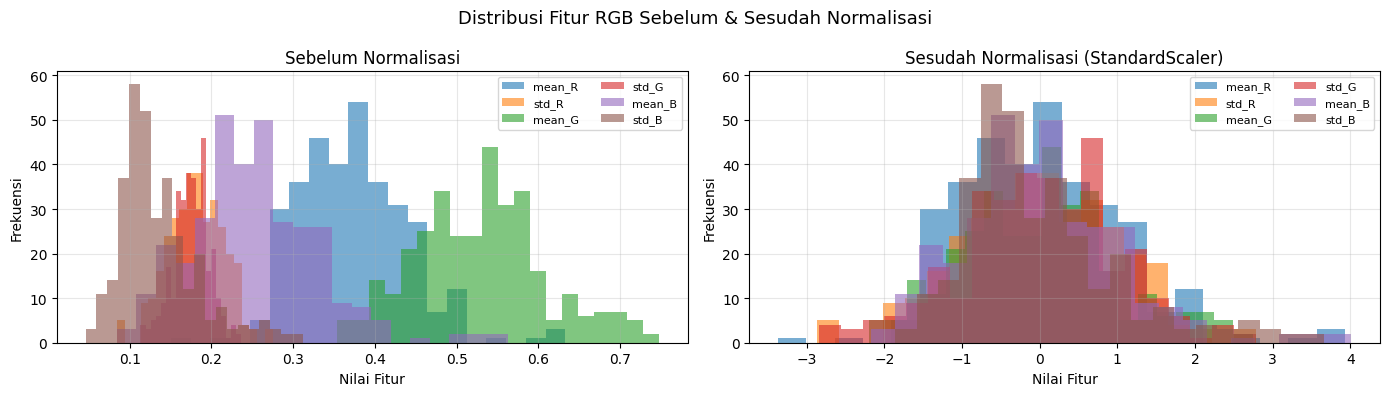

In [ ]:
# Encode label: Sehat=1, Sakit=0
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Encoding label:')
for i, kelas in enumerate(le.classes_):
    print(f'  {kelas} → {i}')

# Normalisasi StandardScaler
# Penting agar fitur dengan skala besar tidak mendominasi
# perhitungan jarak Euclidean pada KNN
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nNormalisasi StandardScaler selesai!')
print(f'  Mean setelah scaling : {X_scaled.mean(axis=0)[:3].round(4)}')
print(f'  Std setelah scaling  : {X_scaled.std(axis=0)[:3].round(4)}')

# Visualisasi distribusi fitur sebelum vs sesudah normalisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in zip(
    axes,
    [X[:, :6], X_scaled[:, :6]],
    ['Sebelum Normalisasi', 'Sesudah Normalisasi (StandardScaler)']
):
    for i, name in enumerate(feature_names[:6]):
        ax.hist(data[:, i], bins=20, alpha=0.6, label=name)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Nilai Fitur')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.suptitle('Distribusi Fitur RGB Sebelum & Sesudah Normalisasi', fontsize=13)
plt.tight_layout()
plt.savefig('distribusi_normalisasi.png', dpi=120, bbox_inches='tight')
plt.show()

# **8. Split Data Train & Test**

In [ ]:
# 80% data untuk training, 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # pastikan proporsi kelas seimbang
)

print('Split data selesai!')
print(f'  Total data   : {len(X_scaled)}')
print(f'  Data train   : {len(X_train)} ({len(X_train)/len(X_scaled)*100:.0f}%)')
print(f'  Data test    : {len(X_test)}  ({len(X_test)/len(X_scaled)*100:.0f}%)')
print()
print(f'  Distribusi train:')
for i, kelas in enumerate(le.classes_):
    n = (y_train == i).sum()
    print(f'    {kelas} : {n}')
print(f'  Distribusi test:')
for i, kelas in enumerate(le.classes_):
    n = (y_test == i).sum()
    print(f'    {kelas} : {n}')

Split data selesai!
  Total data   : 331
  Data train   : 264 (80%)
  Data test    : 67  (20%)

  Distribusi train:
    Sakit : 160
    Sehat : 104
  Distribusi test:
    Sakit : 40
    Sehat : 27


# **9. Cari Nilai K Optimal + Training KNN**

Mencari nilai K optimal (K=1 sampai K=20)...
  K= 1 | Train Acc=1.0000 | Test Acc=1.0000
  K= 2 | Train Acc=0.9924 | Test Acc=1.0000
  K= 3 | Train Acc=0.9811 | Test Acc=0.9851
  K= 4 | Train Acc=0.9697 | Test Acc=1.0000
  K= 5 | Train Acc=0.9697 | Test Acc=0.9701
  K= 6 | Train Acc=0.9621 | Test Acc=0.9701
  K= 7 | Train Acc=0.9470 | Test Acc=0.9701
  K= 8 | Train Acc=0.9394 | Test Acc=0.9851
  K= 9 | Train Acc=0.9242 | Test Acc=0.9701
  K=10 | Train Acc=0.9167 | Test Acc=0.9851
  K=11 | Train Acc=0.9129 | Test Acc=0.9851
  K=12 | Train Acc=0.9167 | Test Acc=0.9851
  K=13 | Train Acc=0.9053 | Test Acc=0.9701
  K=14 | Train Acc=0.8977 | Test Acc=0.9552
  K=15 | Train Acc=0.9053 | Test Acc=0.9552
  K=16 | Train Acc=0.8977 | Test Acc=0.9552
  K=17 | Train Acc=0.8939 | Test Acc=0.9552
  K=18 | Train Acc=0.8864 | Test Acc=0.9552
  K=19 | Train Acc=0.8902 | Test Acc=0.9552
  K=20 | Train Acc=0.8864 | Test Acc=0.9552

K optimal: K = 1
Test Accuracy terbaik: 1.0000


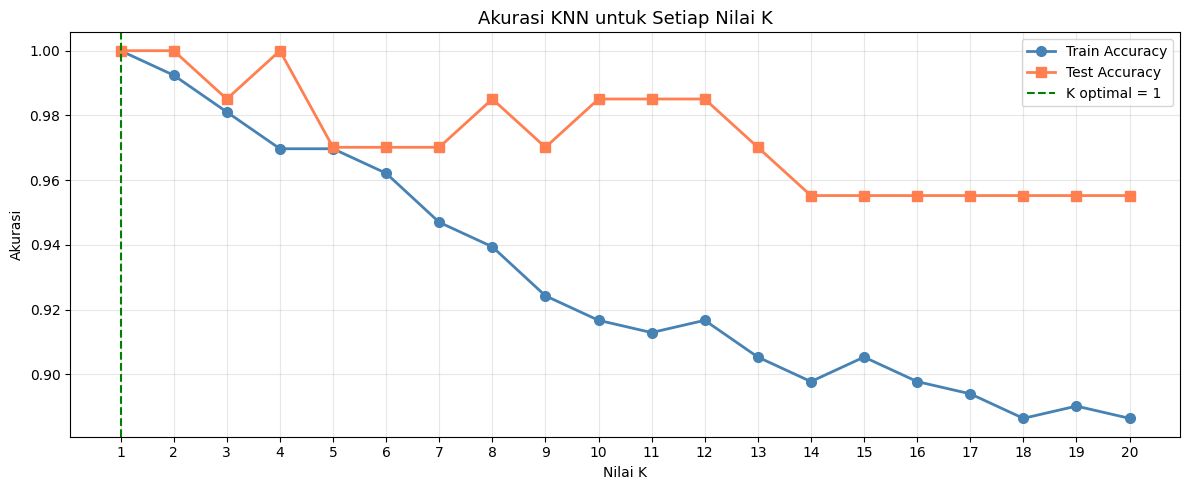

In [ ]:
# -------------------------------------------------------
# PROSES MATEMATIS KNN:
# 1. Hitung jarak Euclidean dari data uji ke semua data latih
#    d(x, xi) = sqrt( sum( (x_j - xi_j)^2 ) ) untuk j=1..28 fitur
# 2. Ambil K tetangga terdekat
# 3. Majority voting: kelas terbanyak dari K tetangga = hasil prediksi
# -------------------------------------------------------

k_range = range(1, 21)
train_scores = []
test_scores  = []

print('Mencari nilai K optimal (K=1 sampai K=20)...')
for k in k_range:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean',  # jarak Euclidean
        weights='uniform'    # semua tetangga bobotnya sama
    )
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))
    print(f'  K={k:2d} | Train Acc={train_scores[-1]:.4f} | Test Acc={test_scores[-1]:.4f}')

# Pilih K dengan test accuracy tertinggi
best_k = list(k_range)[np.argmax(test_scores)]
print(f'\nK optimal: K = {best_k}')
print(f'Test Accuracy terbaik: {max(test_scores):.4f}')

# Plot akurasi
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_range, train_scores, 'o-', color='steelblue',
        linewidth=2, markersize=7, label='Train Accuracy')
ax.plot(k_range, test_scores, 's-', color='coral',
        linewidth=2, markersize=7, label='Test Accuracy')
ax.axvline(x=best_k, color='green', linestyle='--',
           linewidth=1.5, label=f'K optimal = {best_k}')
ax.set_title('Akurasi KNN untuk Setiap Nilai K', fontsize=13)
ax.set_xlabel('Nilai K')
ax.set_ylabel('Akurasi')
ax.set_xticks(list(k_range))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('akurasi_per_k.png', dpi=120, bbox_inches='tight')
plt.show()

# **10. Evaluasi Model KNN**

   EVALUASI MODEL KNN
  K optimal         : 1
  Accuracy          : 1.0000 (100.00%)
  F1-Score          : 1.0000

  Classification Report:
              precision    recall  f1-score   support

       Sakit       1.00      1.00      1.00        40
       Sehat       1.00      1.00      1.00        27

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



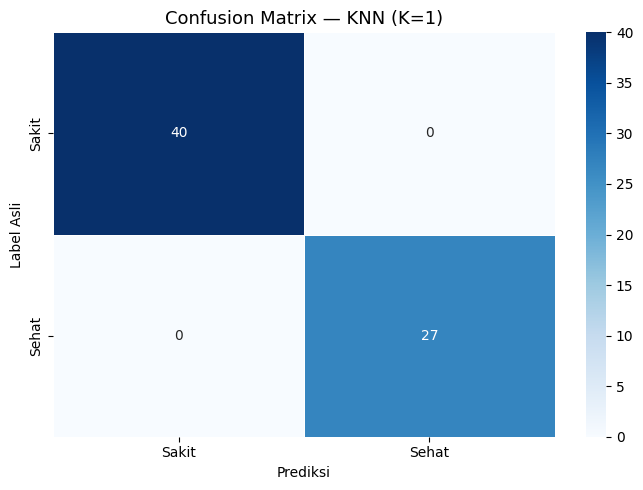

In [ ]:
# Training ulang dengan K optimal
knn_best = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean',
    weights='uniform'
)
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

# Metrik evaluasi
accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred, average='weighted')
cm        = confusion_matrix(y_test, y_pred)
report    = classification_report(y_test, y_pred,
                                   target_names=le.classes_)

print('=' * 55)
print('   EVALUASI MODEL KNN')
print('=' * 55)
print(f'  K optimal         : {best_k}')
print(f'  Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  F1-Score          : {f1:.4f}')
print()
print('  Classification Report:')
print(report)
print('=' * 55)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix — KNN (K={best_k})', fontsize=13)
ax.set_xlabel('Prediksi')
ax.set_ylabel('Label Asli')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# **11. Visualisasi PCA 2D**

Variansi PC1: 21.3%
Variansi PC2: 19.2%
Total       : 40.5%


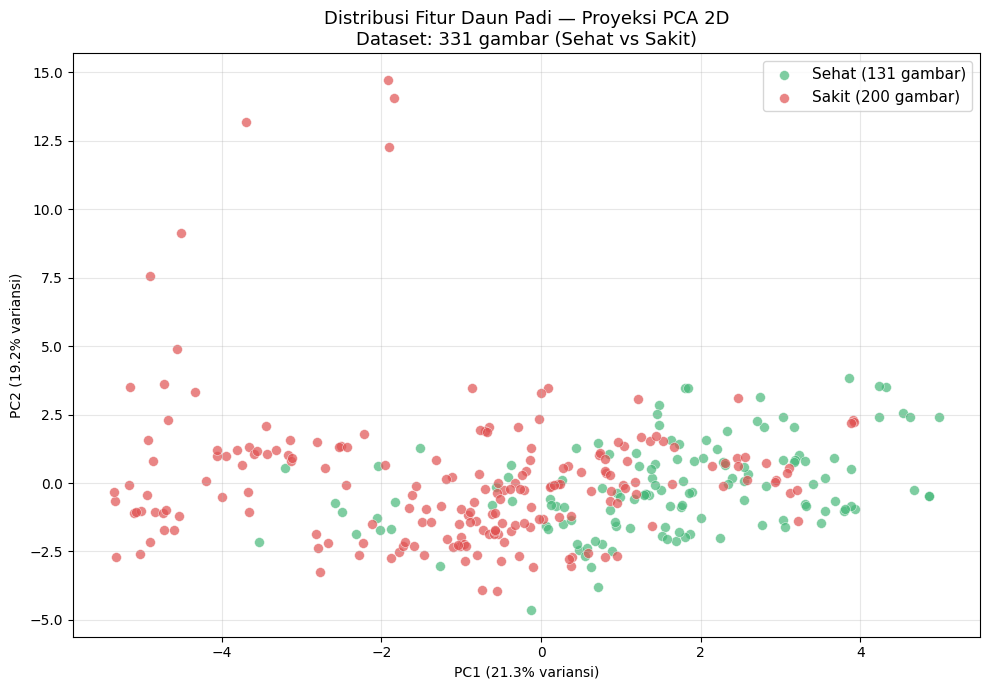

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f'Variansi PC1: {ev[0]*100:.1f}%')
print(f'Variansi PC2: {ev[1]*100:.1f}%')
print(f'Total       : {sum(ev)*100:.1f}%')

WARNA = {'Sehat': '#47B87A', 'Sakit': '#E05252'}

plt.figure(figsize=(10, 7))
for kelas, warna in WARNA.items():
    mask = y == kelas
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=warna, label=f'{kelas} ({mask.sum()} gambar)',
                alpha=0.7, s=50,
                edgecolors='white', linewidth=0.4)

plt.title(f'Distribusi Fitur Daun Padi — Proyeksi PCA 2D\n'
          f'Dataset: {len(X_scaled)} gambar (Sehat vs Sakit)', fontsize=13)
plt.xlabel(f'PC1 ({ev[0]*100:.1f}% variansi)')
plt.ylabel(f'PC2 ({ev[1]*100:.1f}% variansi)')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_daun_padi.png', dpi=120, bbox_inches='tight')
plt.show()

# **12. Ringkasan Akhir**

In [ ]:
print('=' * 55)
print('   RINGKASAN HASIL KLASIFIKASI DAUN PADI')
print('=' * 55)
print(f'  Dataset          : Rice Leaf Diseases (Kaggle)')
print(f'  Total gambar     : {len(X_scaled)}')
print(f'    Sehat          : {(y == "Sehat").sum()}')
print(f'    Sakit          : {(y == "Sakit").sum()}')
print(f'  Jumlah fitur     : {X.shape[1]}')
print(f'    RGB            : 6 fitur')
print(f'    HSV Histogram  : 18 fitur')
print(f'    GLCM Tekstur   : 4 fitur')
print()
print(f'  Metode ML        : K-Nearest Neighbor (KNN)')
print(f'  K optimal        : {best_k}')
print(f'  Split data       : 80% train / 20% test')
print()
print('  METRIK EVALUASI:')
print(f'  Accuracy         : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'  F1-Score         : {f1:.4f}')
print()
print('  Confusion Matrix:')
for i, kelas in enumerate(le.classes_):
    print(f'    {kelas}: {cm[i]}')
print('=' * 55)

# Simpan hasil ke CSV
df['prediksi'] = [''] * len(df)
df.to_csv('hasil_klasifikasi_daun_padi.csv', index=False)

# Download file CSV
from google.colab import files
files.download('dataset_fitur_daun_padi.csv')
files.download('hasil_klasifikasi_daun_padi.csv')
print('\nFile CSV berhasil didownload!')

   RINGKASAN HASIL KLASIFIKASI DAUN PADI
  Dataset          : Rice Leaf Diseases (Kaggle)
  Total gambar     : 331
    Sehat          : 131
    Sakit          : 200
  Jumlah fitur     : 28
    RGB            : 6 fitur
    HSV Histogram  : 18 fitur
    GLCM Tekstur   : 4 fitur

  Metode ML        : K-Nearest Neighbor (KNN)
  K optimal        : 1
  Split data       : 80% train / 20% test

  METRIK EVALUASI:
  Accuracy         : 1.0000 (100.00%)
  F1-Score         : 1.0000

  Confusion Matrix:
    Sakit: [40  0]
    Sehat: [ 0 27]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


File CSV berhasil didownload!
